In [1]:
import asyncio
from collections import defaultdict
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
import sys
from pathlib import Path

# Asumiendo que notebooks/ está dentro de la raíz del proyecto
root_path = Path().resolve().parent  # sube un nivel
sys.path.append(str(root_path))

In [3]:
from agents.classifier_agent import ClassifierAgent
from agents.aggregator_agent import AggregatorAgent
from data.dataset_registry import DatasetRegistry
from data.loaders.sklearn_loader import SklearnLoader
import pandas as pd


==================== TEST MULTI-AGENT (WINE + SHAP + LIME) ====================
[Dataset] wine cargado → X=(178, 13), y=(178,)
[Dataset] Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

[Instancia] Índice frontera: 83
[Instancia] Clase real: 1
[Instancia] Probabilidades (RF ref): [0.03 0.73 0.24]
[Instancia] Entropía: 0.6774

[Setup] Inicializando agentes...

[rf_adaptive] Setup iniciado
[rf_adaptive] 14:48:33 | Setup iniciado (train + eval inicial)
[rf_adaptive] 14:48:33 | Entrenando modelo (iter=0)
[rf_adaptive] 14:48:33 | Evaluación completada | acc=0.944
[rf_adaptive] 14:48:33 | Setup completado
[gb_adaptive] Setup iniciado
[gb_adaptive] 14:48:33 | Setup iniciado (train + eval inicial)
[gb_adaptive] 14:48:33 | Entrenando modelo (iter=0)
[gb_adaptive] 14:48:33 | Evaluación completada | acc=0.972
[gb_adaptive] 14:

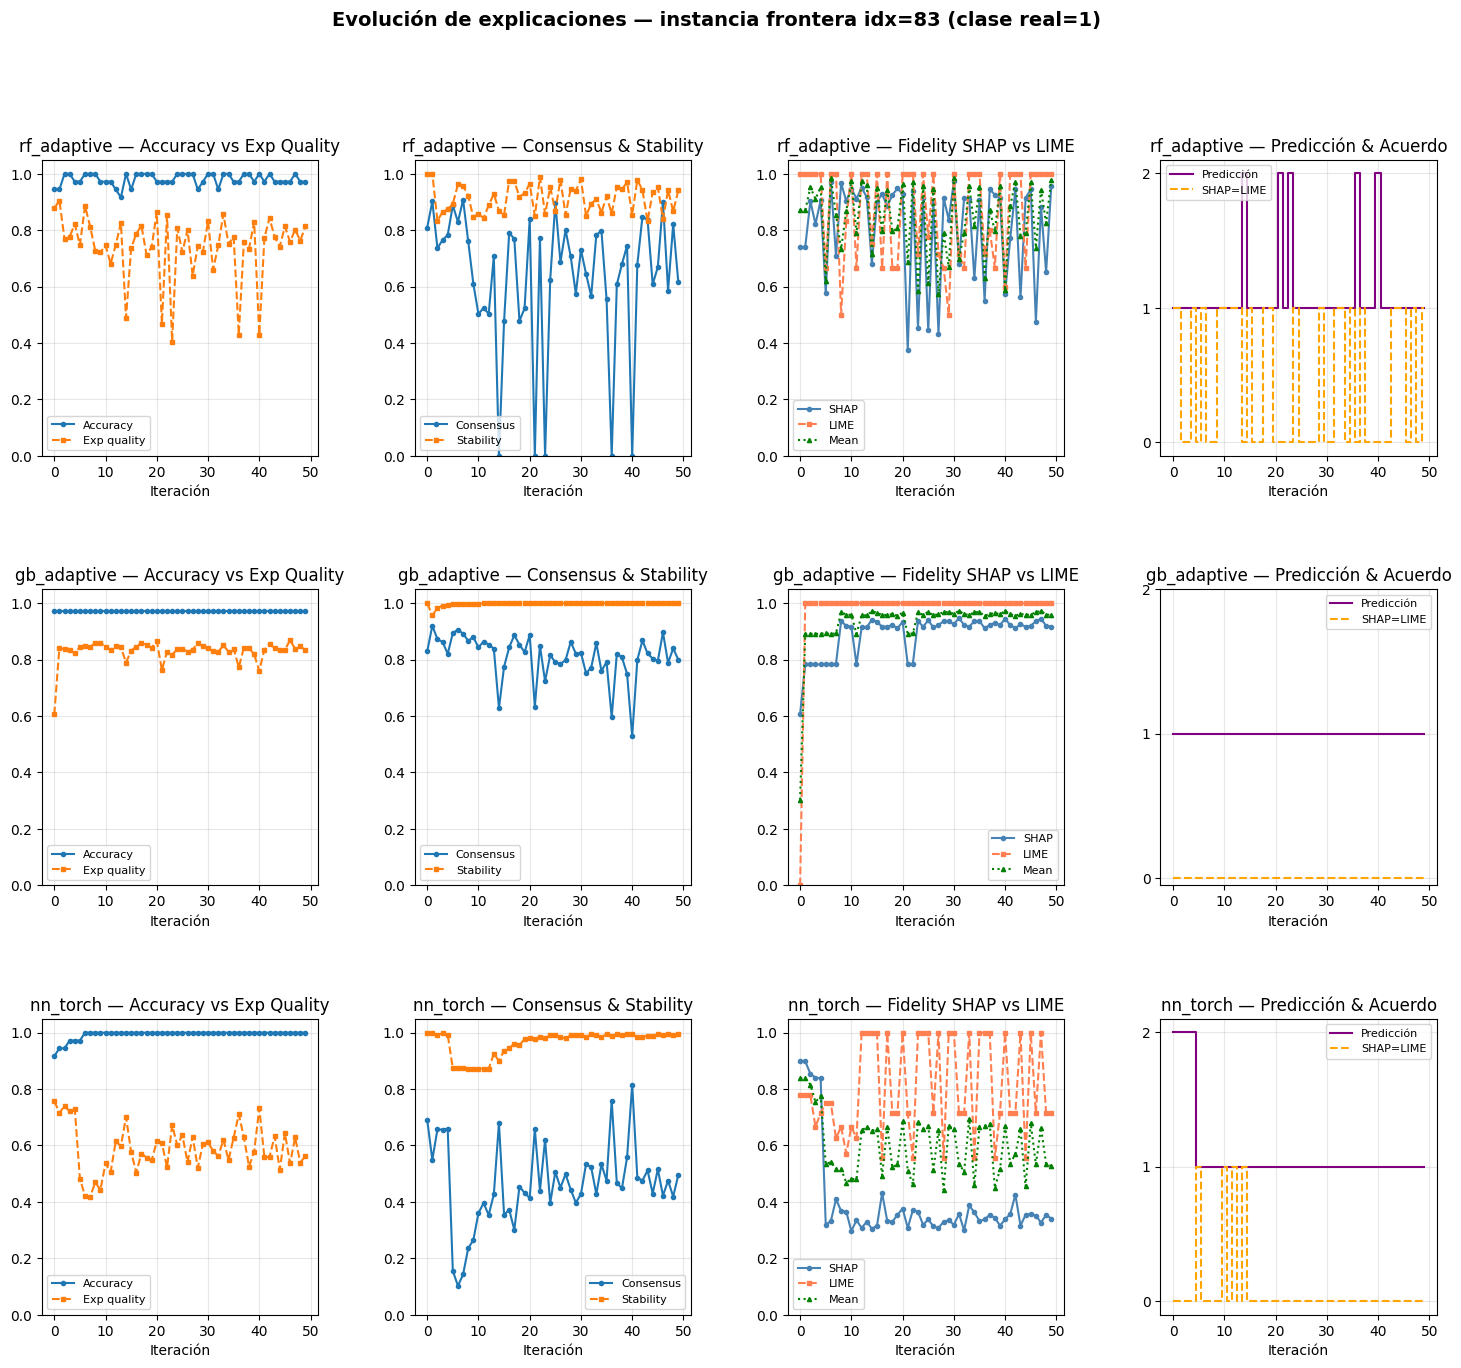


[Resumen] Medias por agente:
             accuracy     f1  exp_quality  exp_consensus  exp_stability  \
agent                                                                     
gb_adaptive     0.972  0.972        0.831          0.812          0.998   
nn_torch        0.994  0.994        0.589          0.465          0.965   
rf_adaptive     0.981  0.980        0.745          0.637          0.913   

             exp_fidelity  exp_agreement  
agent                                     
gb_adaptive         0.936          0.326  
nn_torch            0.600          0.106  
rf_adaptive         0.840          0.466  

[Resumen] Evolución media por iteración (primeras 10):
           accuracy  exp_quality  exp_fidelity  exp_agreement
iteration                                                    
0             0.944        0.747         0.671          0.374
1             0.954        0.821         0.867          0.462
2             0.972        0.782         0.887          0.297
3            

,agent,iteration,accuracy,f1,precision,recall,prediction,confidence,exp_quality,exp_consensus,...,shap_consensus,shap_stability,shap_fidelity,lime_consensus,lime_stability,lime_fidelity,shap_top_feature,lime_top_feature,shap_lime_agree,decision
0,gb_adaptive,0,0.972222,0.972525,0.975309,0.972222,1,0.562387,0.605911,0.829018,...,0.829018,1.000000,0.607558,0.969095,1.000000,0.000000,flavanoids,color_intensity,False,soft_adjust
1,gb_adaptive,1,0.972222,0.971775,0.974074,0.972222,1,0.998529,0.842640,0.920522,...,0.920522,0.976035,0.783146,0.945494,0.937366,0.999999,flavanoids,color_intensity,False,keep
2,gb_adaptive,2,0.972222,0.971775,0.974074,0.972222,1,0.998529,0.836483,0.872484,...,0.872484,0.992095,0.783146,0.896901,0.975121,0.999999,flavanoids,color_intensity,False,keep
3,gb_adaptive,3,0.972222,0.971775,0.974074,0.972222,1,0.998529,0.834030,0.862911,...,0.862911,0.995925,0.783146,0.897341,0.986857,0.999999,flavanoids,color_intensity,False,keep
4,gb_adaptive,4,0.972222,0.971775,0.974074,0.972222,1,0.998529,0.822095,0.820379,...,0.820379,0.997469,0.783146,0.907987,0.991912,0.999999,flavanoids,color_intensity,False,keep
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,rf_adaptive,45,0.972222,0.972187,0.974074,0.972222,1,0.990627,0.813461,0.669347,...,0.669347,0.957284,0.945055,0.964988,0.949906,0.999998,color_intensity,color_intensity,True,soft_adjust
146,rf_adaptive,46,0.972222,0.972187,0.974074,0.972222,1,0.615439,0.758906,0.900682,...,0.900682,0.750000,0.475275,0.955351,0.927793,0.999999,flavanoids,color_intensity,False,soft_adjust
147,rf_adaptive,47,1.000000,1.000000,1.000000,1.000000,1,0.942048,0.802318,0.586285,...,0.586285,0.938348,0.883984,0.892561,0.945668,0.999997,color_intensity,color_intensity,True,soft_adjust
148,rf_adaptive,48,0.972222,0.972187,0.974074,0.972222,1,0.657339,0.762613,0.821400,...,0.821400,0.758695,0.651099,0.950588,0.975537,0.999998,flavanoids,color_intensity,False,soft_adjust


In [ ]:
"""
experiments.py
==============
Experimento completo para el TFG:
"Modelado de explicaciones dinámicas en sistemas multiagente"

6 preguntas de investigación
-----------------------------
P1. ¿Las explicaciones mejoran con las iteraciones?
    → Evolución de exp_quality, fidelity y consensus por iteración

P2. ¿El mecanismo de mentor funciona?
    → Ablación sin mentor: convergencia más lenta, peor exp_quality

P3. ¿SHAP y LIME se coordinan?
    → Evolución del acuerdo shap_lime_agree por dataset

P4. ¿El sistema se adapta a la dificultad de la instancia?
    → Delta accuracy y exp_quality: frontera vs fácil

P5. ¿El cooldown y el weighted vote tienen efecto real?
    → Ablación sin cooldown y con voto simple

P6. ¿El comportamiento varía según el tipo de modelo?
    → Fidelity SHAP y LIME por tipo de modelo (boxplot)

Estructura de runs
------------------
Base    : 5 grupos × 3 datasets × 2 instancias = 30 runs
Ablación: G1 × 3 datasets × 3 condiciones      =  9 runs
Total   : 39 runs

Grupos
------
G1 : RandomForest     + GradientBoosting + TorchMLP
G2 : XGBoost          + LinearSVM        + LogisticRegression
G3 : KNN              + RandomForest     + XGBoost
G4 : TorchMLP         + LinearSVM        + GradientBoosting
G5 : LogisticRegression + KNN            + TorchMLP

Datasets
--------
- Wine      (178  × 13,  3 clases)
- Digits    (1797 × 64, 10 clases)
- Covertype (5000 × 54,  7 clases)

Figuras generadas (TFG)
-----------------------
Fig 1 — P1: Evolución media de exp_quality, fidelity y consensus
             a lo largo de las iteraciones (3 subplots, uno por dataset)
Fig 2 — P2: Ablación mentor — accuracy y exp_quality final por condición
Fig 3 — P3: Evolución del acuerdo SHAP=LIME por dataset
Fig 4 — P4: Heatmap delta (fácil − frontera) de accuracy y exp_quality
Fig 5 — P5: Ablación cooldown y voto — barplot de iteraciones hasta parada
Fig 6 — P6: Boxplot de fidelity SHAP y LIME por tipo de modelo
Tabla 1    : Resumen numérico completo por grupo × dataset
"""

import asyncio
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch.nn as nn

from sklearn.datasets      import load_wine, load_digits, fetch_covtype
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble      import RandomForestClassifier as _RFC
from sklearn.utils         import resample

from data.dataset_registry   import DatasetRegistry
from agents.classifier_agent import ClassifierAgent
from agents.aggregator_agent import AggregatorAgent

from explainers.shap_explainer import ShapExplainer
from explainers.lime_explainer import LimeExplainer

from models.random_forest       import RandomForest
from models.gradient_boosting   import GradientBoostingModel
from models.xgboost             import XGBoostModel
from models.linearSVM           import LinearSVM
from models.logistic_regression import LogisticRegressionModel
from models.kNN                 import KNNModel
from models.torch_model         import TorchModel

from visualization.visualization import build_results_dataframe

warnings.filterwarnings("ignore")


# ================================================================
# Constantes
# ================================================================

GROUPS = {
    "G1": ["rf",    "gb",   "torch"],
    "G2": ["xgb",   "svm",  "lr"],
    "G3": ["knn",   "rf",   "xgb"],
    "G4": ["torch", "svm",  "gb"],
    "G5": ["lr",    "knn",  "torch"],
}

MODEL_LABELS = {
    "rf":    "RandomForest",
    "gb":    "GradientBoosting",
    "xgb":   "XGBoost",
    "svm":   "LinearSVM",
    "lr":    "LogisticRegression",
    "knn":   "KNN",
    "torch": "TorchMLP",
}

MODEL_TYPE = {
    "rf":    "Ensemble",
    "gb":    "Ensemble",
    "xgb":   "Ensemble",
    "svm":   "Lineal",
    "lr":    "Lineal",
    "knn":   "Distancia",
    "torch": "Red neuronal",
}

ABLATION_GROUP     = "G1"
CONV_ACC_THRESHOLD = 0.85
CONV_EXP_THRESHOLD = 0.60
MAX_ITER           = 30


# ================================================================
# Carga de datasets
# ================================================================

def load_datasets() -> dict:
    datasets = {}

    ds = load_wine()
    datasets["wine"] = {
        "X_raw":         ds.data,
        "y":             ds.target,
        "feature_names": list(ds.feature_names),
        "label":         "Wine",
    }

    ds = load_digits()
    datasets["digits"] = {
        "X_raw":         ds.data,
        "y":             ds.target,
        "feature_names": [f"pixel_{i}" for i in range(ds.data.shape[1])],
        "label":         "Digits",
    }

    ds = fetch_covtype()
    X_cv, y_cv = resample(ds.data, ds.target - 1,
                           n_samples=5000, random_state=42,
                           stratify=ds.target - 1)
    datasets["covertype"] = {
        "X_raw":         X_cv,
        "y":             y_cv,
        "feature_names": [f"f{i}" for i in range(X_cv.shape[1])],
        "label":         "Covertype",
    }

    return datasets


# ================================================================
# Helpers
# ================================================================

class ScaledLoader:
    def __init__(self, X, y, feature_names):
        self.X, self.y, self.feature_names = X, y, feature_names

    def load(self):
        return self.X, self.y, {
            "feature_names": self.feature_names,
            "n_samples":     self.X.shape[0],
            "n_features":    self.X.shape[1],
        }


def select_instances(X, y):
    rf  = _RFC(n_estimators=100, random_state=42).fit(X, y)
    pr  = rf.predict_proba(X)
    ent = -np.sum(pr * np.log(pr + 1e-8), axis=1)
    return int(np.argmax(ent)), int(np.argmax(pr.max(axis=1)))


class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        h = max(32, input_dim * 2)
        self.net = nn.Sequential(
            nn.Linear(input_dim, h), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(h, h // 2),   nn.ReLU(),
            nn.Linear(h // 2, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def make_model(name, input_dim, num_classes):
    if name == "rf":    return RandomForest(n_estimators=5, max_depth=2, random_state=0)
    if name == "gb":    return GradientBoostingModel(n_estimators=5, learning_rate=0.9, max_depth=1)
    if name == "xgb":   return XGBoostModel(n_estimators=5, learning_rate=0.9, max_depth=1)
    if name == "svm":   return LinearSVM(C=0.01, max_iter=500)
    if name == "lr":    return LogisticRegressionModel(C=0.01, max_iter=100)
    if name == "knn":   return KNNModel(n_neighbors=15)
    if name == "torch": return TorchModel(
        nn_model=MLP(input_dim, num_classes),
        lr=1e-3, min_lr=1e-5, max_lr=0.05, epochs=15, batch_size=32)
    raise ValueError(name)


def make_explainers(feature_names, class_names):
    return [
        ShapExplainer(feature_names=feature_names),
        LimeExplainer(
            feature_names=feature_names,
            class_names=class_names,
            discretize_continuous=False,
        ),
    ]


# ================================================================
# Extracción de logs desde global_history
# ================================================================

def extract_weighted_diff(history):
    """Iteraciones donde weighted vote ≠ voto simple."""
    return sum(
        1 for e in history
        if e["evaluation"]["majority_prediction"] !=
           max(set(r["prediction"] for r in e["responses"]),
               key=lambda p: sum(1 for r in e["responses"]
                                 if r["prediction"] == p))
    )


def extract_mentor_activations(history):
    """
    Cuenta activaciones de mentor inferidas desde evaluación.
    Existe mentor si hay al menos un agente con quality>=0.60,
    fidelity>=0.60 y confianza>=0.50 alineado con la mayoría.
    """
    count, dissent = 0, 0
    for e in history:
        ev     = e["evaluation"]
        maj    = ev["majority_prediction"]
        resp   = e["responses"]
        detail = ev["components"]["exp_detail"]
        q_arr  = detail.get("quality",  [0.5] * len(resp))
        f_arr  = detail.get("fidelity", [0.5] * len(resp))
        c_arr  = ev["components"].get("conf", [0.0] * len(resp))
        preds  = [r["prediction"] for r in resp]

        aligned = [i for i, (q, f, c, p) in enumerate(
            zip(q_arr, f_arr, c_arr, preds))
            if p == maj and q >= 0.60 and f >= 0.60 and c >= 0.50]

        if aligned:
            count += 1
        else:
            dissident = [i for i, (q, f, c, p) in enumerate(
                zip(q_arr, f_arr, c_arr, preds))
                if p != maj and q >= 0.65 and f >= 0.70 and c >= 0.55]
            if dissident:
                count   += 1
                dissent += 1

    return count, dissent


def extract_cooldown_activations(history, classifier_ids):
    """
    Cuenta activaciones de cooldown:
    decisión != keep pero iters_since_adjust no se resetó.
    """
    total = 0
    isa   = {cid: [] for cid in classifier_ids}
    dec   = {cid: [] for cid in classifier_ids}

    for e in history:
        for idx, cid in enumerate(classifier_ids):
            isa[cid].append(e["responses"][idx].get("iters_since_adjust", None))
            dec[cid].append(e["decisions"][idx]
                            if idx < len(e["decisions"]) else "unknown")

    for cid in classifier_ids:
        for i in range(1, len(isa[cid])):
            p, c = isa[cid][i - 1], isa[cid][i]
            d    = dec[cid][i]
            if (p is not None and c is not None
                    and d not in ("keep",) and c > 0 and c >= p):
                total += 1
    return total


def compute_convergence_iter(df, classifier_ids):
    """
    Para cada agente: primera iteración donde accuracy >= umbral
    y primera donde exp_quality >= umbral.
    """
    result = {}
    for aid in classifier_ids:
        sub = df[df["agent"] == aid].sort_values("iteration")
        ia  = sub.loc[sub["accuracy"]    >= CONV_ACC_THRESHOLD, "iteration"]
        ie  = sub.loc[sub["exp_quality"] >= CONV_EXP_THRESHOLD, "iteration"]
        i_a = int(ia.iloc[0]) if not ia.empty else -1
        i_e = int(ie.iloc[0]) if not ie.empty else -1

        if i_a == -1 and i_e == -1:   order = "never"
        elif i_a == -1:                order = "exp_first"
        elif i_e == -1:                order = "acc_first"
        elif abs(i_a - i_e) <= 1:     order = "simultaneous"
        elif i_a < i_e:                order = "acc_first"
        else:                          order = "exp_first"

        result[aid] = {"iter_acc": i_a, "iter_exp": i_e, "order": order}
    return result


# ================================================================
# Run único
# ================================================================

async def run_single(group_name, model_names, dataset_name,
                     X_scaled, y, feature_names, instance,
                     instance_label, max_iterations=MAX_ITER,
                     mentor_enabled=True, cooldown_enabled=True,
                     weighted_vote=True):

    class_names = [str(c) for c in np.unique(y)]
    num_classes = len(class_names)
    input_dim   = X_scaled.shape[1]

    registry = DatasetRegistry()
    registry.register("ds", ScaledLoader(X_scaled, y, feature_names))

    classifiers    = {}
    classifier_ids = []
    for mn in model_names:
        aid = f"{mn}_{group_name}_{dataset_name}"
        classifiers[aid] = ClassifierAgent(
            agent_id=aid,
            model=make_model(mn, input_dim, num_classes),
            explainers=make_explainers(feature_names, class_names),
            dataset_id="ds",
            registry=registry,
        )
        classifier_ids.append(aid)

    aggregator = AggregatorAgent(
        classifier_ids=classifier_ids,
        max_iterations=max_iterations,
        background_data=X_scaled,
    )

    # ── Flags de ablación ─────────────────────────────────────────
    if not weighted_vote:
        aggregator.evaluator._weighted_majority_vote = \
            lambda preds, accs, confs, fids=None: max(
                set(preds), key=preds.count)

    if not mentor_enabled:
        aggregator.feedback_builder.find_mentor = \
            lambda responses, evaluation: (None, [], False)

    if not cooldown_enabled:
        for ag in classifiers.values():
            type(ag)._cooldown_threshold = property(lambda self: 9999)

    queues = {aid: ag.inbox for aid, ag in classifiers.items()}
    queues["aggregator"] = aggregator.inbox

    await asyncio.gather(*(ag.setup() for ag in classifiers.values()))
    tasks = [asyncio.create_task(ag.run(queues))
             for ag in classifiers.values()]
    tasks.append(asyncio.create_task(aggregator.run(queues, instance)))
    await asyncio.gather(*tasks, return_exceptions=True)

    history = aggregator.global_history
    df = build_results_dataframe(
        aggregator_history=history,
        classifier_ids=classifier_ids,
        feature_names=feature_names,
    )

    stop_entries = [e for e in history if e["stop"]]
    stopped_at   = stop_entries[0]["iteration"] if stop_entries else -1

    n_mentor, n_dissent = extract_mentor_activations(history)
    n_cooldown          = extract_cooldown_activations(history, classifier_ids)
    weighted_diff       = extract_weighted_diff(history)
    conv                = compute_convergence_iter(df, classifier_ids)

    return {
        "df":             df,
        "history":        history,
        "classifier_ids": classifier_ids,
        "model_names":    model_names,
        "group_name":     group_name,
        "dataset_name":   dataset_name,
        "instance_label": instance_label,
        "stopped_at":     stopped_at,
        "n_mentor":       n_mentor,
        "n_dissent":      n_dissent,
        "n_cooldown":     n_cooldown,
        "weighted_diff":  weighted_diff,
        "convergence":    conv,
    }


# ================================================================
# FIGURA 1 — P1: Evolución de explicabilidad por dataset
# ================================================================

def fig1_explainability_evolution(all_hard: dict, dataset_names: list):
    """
    3 subplots (uno por dataset) con la evolución media de
    exp_quality, fidelity y consensus. Se promedian todos los
    agentes y grupos de ese dataset.
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    fig.suptitle(
        "P1 — Evolución de la calidad explicativa por iteración",
        fontsize=13, fontweight="bold"
    )

    for ax, dn in zip(axes, dataset_names):
        frames = [r["df"] for (gn, d), r in all_hard.items()
                  if d == dn and not r["df"].empty]
        if not frames:
            ax.set_title(dn)
            continue

        combined = pd.concat(frames)
        grouped  = combined.groupby("iteration").agg(
            exp_quality_mean=("exp_quality",  "mean"),
            exp_quality_std=("exp_quality",   "std"),
            exp_fidelity_mean=("exp_fidelity","mean"),
            exp_fidelity_std=("exp_fidelity", "std"),
            exp_consensus_mean=("exp_consensus","mean"),
            exp_consensus_std=("exp_consensus", "std"),
        ).reset_index()

        iters = grouped["iteration"]

        for col, label, color in [
            ("exp_quality",   "Exp Quality", "steelblue"),
            ("exp_fidelity",  "Fidelity",    "coral"),
            ("exp_consensus", "Consensus",   "seagreen"),
        ]:
            m = grouped[f"{col}_mean"]
            s = grouped[f"{col}_std"].fillna(0)
            ax.plot(iters, m, label=label, color=color,
                    marker="o", markersize=3, linewidth=1.5)
            ax.fill_between(iters, m - s, m + s, color=color, alpha=0.12)

        ax.axhline(CONV_EXP_THRESHOLD, color="gray", linestyle=":",
                   linewidth=1, alpha=0.6)
        ax.set_title(dn, fontweight="bold")
        ax.set_xlabel("Iteración")
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
        if ax == axes[0]:
            ax.set_ylabel("Score")
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


# ================================================================
# FIGURA 2 — P2: Ablación mentor
# ================================================================

def fig2_mentor_ablation(ablation_results: dict, dataset_names: list):
    """
    Barplot comparando sistema completo vs sin mentor:
    accuracy final y exp_quality final por dataset.
    """
    conditions  = ["completo", "sin_mentor"]
    cond_colors = {"completo": "steelblue", "sin_mentor": "salmon"}
    cond_labels = {"completo": "Sistema completo", "sin_mentor": "Sin mentor"}

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("P2 — Efecto del mecanismo de mentor (ablación)",
                 fontsize=13, fontweight="bold")

    x = np.arange(len(dataset_names))
    w = 0.35

    for ax, (metric, ylabel) in zip(axes, [
        ("acc_final",  "Accuracy final"),
        ("expq_final", "Exp Quality final"),
    ]):
        for ci, cond in enumerate(conditions):
            vals, errs = [], []
            for dn in dataset_names:
                r = ablation_results.get((cond, dn))
                if r and not r["df"].empty:
                    last = r["df"]["iteration"].max()
                    col  = "accuracy" if metric == "acc_final" else "exp_quality"
                    v    = r["df"][r["df"]["iteration"] == last][col]
                    vals.append(v.mean())
                    errs.append(v.std())
                else:
                    vals.append(np.nan)
                    errs.append(0)

            offset = (ci - 0.5) * w
            bars = ax.bar(x + offset, vals, w, yerr=errs,
                          label=cond_labels[cond],
                          color=cond_colors[cond],
                          alpha=0.85, capsize=4)

            # Anotar delta respecto al completo
            if cond == "sin_mentor":
                for xi, (v, bar) in enumerate(zip(vals, bars)):
                    comp = ablation_results.get(("completo", dataset_names[xi]))
                    if comp and not comp["df"].empty:
                        last  = comp["df"]["iteration"].max()
                        col   = "accuracy" if metric == "acc_final" else "exp_quality"
                        v_ref = comp["df"][comp["df"]["iteration"] == last][col].mean()
                        delta = v - v_ref
                        if not np.isnan(delta):
                            ax.text(bar.get_x() + bar.get_width() / 2,
                                    bar.get_height() + 0.01,
                                    f"{delta:+.2f}", ha="center",
                                    va="bottom", fontsize=7, color="red")

        ax.set_xticks(x)
        ax.set_xticklabels(dataset_names)
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.set_ylim(0, 1.15)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()


# ================================================================
# FIGURA 3 — P3: Acuerdo SHAP vs LIME
# ================================================================

def fig3_shap_lime_agreement(all_hard: dict, dataset_names: list):
    """
    Evolución del acuerdo SHAP=LIME promediado sobre todos los grupos,
    con banda de varianza. Un subplot por dataset.
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    fig.suptitle(
        "P3 — Coordinación SHAP y LIME (acuerdo en top-feature)",
        fontsize=13, fontweight="bold"
    )

    for ax, dn in zip(axes, dataset_names):
        frames = [r["df"] for (gn, d), r in all_hard.items()
                  if d == dn and not r["df"].empty]
        if not frames:
            ax.set_title(dn)
            continue

        combined = pd.concat(frames)

        # Acuerdo top-feature SHAP=LIME
        if "shap_lime_agree" in combined.columns:
            g = combined.groupby("iteration")["shap_lime_agree"].agg(["mean", "std"])
            m = g["mean"]
            s = g["std"].fillna(0)
            ax.plot(g.index, m, color="steelblue", linewidth=1.5,
                    marker="o", markersize=3, label="SHAP = LIME")
            ax.fill_between(g.index, m - s, m + s,
                            color="steelblue", alpha=0.15)

        # Acuerdo inter-explainer (exp_agreement del evaluador)
        if "exp_agreement" in combined.columns:
            g2 = combined.groupby("iteration")["exp_agreement"].agg(["mean", "std"])
            m2 = g2["mean"]
            s2 = g2["std"].fillna(0)
            ax.plot(g2.index, m2, color="coral", linewidth=1.5,
                    marker="s", markersize=3, linestyle="--",
                    label="Agreement (evaluador)")
            ax.fill_between(g2.index, m2 - s2, m2 + s2,
                            color="coral", alpha=0.12)

        ax.set_title(dn, fontweight="bold")
        ax.set_xlabel("Iteración")
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        if ax == axes[0]:
            ax.set_ylabel("Fracción de acuerdo")
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


# ================================================================
# FIGURA 4 — P4: Heatmap frontera vs fácil
# ================================================================

def fig4_hard_vs_easy(all_hard: dict, all_easy: dict,
                       dataset_names: list):
    """
    Dos heatmaps (grupo × dataset):
    Δ accuracy y Δ exp_quality = fácil − frontera.
    Valores positivos = frontera más difícil.
    """
    group_names = list(GROUPS.keys())
    delta_acc   = np.full((len(group_names), len(dataset_names)), np.nan)
    delta_expq  = np.full_like(delta_acc, np.nan)

    for i, gn in enumerate(group_names):
        for j, dn in enumerate(dataset_names):
            rh = all_hard.get((gn, dn))
            re = all_easy.get((gn, dn))
            if not rh or not re:
                continue
            if rh["df"].empty or re["df"].empty:
                continue

            def last_mean(r, col):
                last = r["df"]["iteration"].max()
                return r["df"][r["df"]["iteration"] == last][col].mean()

            delta_acc[i, j]  = last_mean(re, "accuracy")    - last_mean(rh, "accuracy")
            delta_expq[i, j] = last_mean(re, "exp_quality") - last_mean(rh, "exp_quality")

    group_labels = [
        f"{gn}: " + "+".join(MODEL_LABELS[m][:3] for m in GROUPS[gn])
        for gn in group_names
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(
        "P4 — Δ (fácil − frontera): impacto de la dificultad de la instancia",
        fontsize=13, fontweight="bold"
    )

    for ax, data, title in zip(axes, [delta_acc, delta_expq],
                                ["Δ Accuracy", "Δ Exp Quality"]):
        sns.heatmap(data, annot=True, fmt=".2f", cmap="RdYlGn",
                    center=0, vmin=-0.3, vmax=0.3,
                    xticklabels=dataset_names,
                    yticklabels=group_labels,
                    ax=ax, linewidths=0.5,
                    cbar_kws={"shrink": 0.8})
        ax.set_title(title, fontweight="bold")
        ax.tick_params(axis="y", labelsize=8)

    plt.tight_layout()
    plt.show()


# ================================================================
# FIGURA 5 — P5: Ablación completa
# ================================================================

def fig5_ablation_cooldown_vote(ablation_results: dict,
                                 dataset_names: list):
    """
    Barplot de iteraciones hasta parada y accuracy final
    para las 4 condiciones.
    """
    conditions  = ["completo", "sin_mentor", "sin_cooldown", "voto_simple"]
    cond_labels = {
        "completo":     "Completo",
        "sin_mentor":   "Sin mentor",
        "sin_cooldown": "Sin cooldown",
        "voto_simple":  "Voto simple",
    }
    colors = ["steelblue", "salmon", "gold", "mediumpurple"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(
        "P5 — Ablación completa: efecto de cada componente del sistema",
        fontsize=13, fontweight="bold"
    )

    x = np.arange(len(dataset_names))
    w = 0.18

    for ax, (metric, ylabel, ylim) in zip(axes, [
        ("stopped_at", "Iteraciones hasta parada\n(-1 = no convergió)", (-2, 35)),
        ("acc_final",  "Accuracy final", (0, 1.15)),
    ]):
        for ci, (cond, col) in enumerate(zip(conditions, colors)):
            vals = []
            for dn in dataset_names:
                r = ablation_results.get((cond, dn))
                if r and not r["df"].empty:
                    if metric == "stopped_at":
                        v = r["stopped_at"]
                    else:
                        last = r["df"]["iteration"].max()
                        v    = r["df"][r["df"]["iteration"] == last]["accuracy"].mean()
                else:
                    v = np.nan
                vals.append(v)

            offset = (ci - len(conditions) / 2 + 0.5) * w
            ax.bar(x + offset, vals, w, label=cond_labels[cond],
                   color=col, alpha=0.85)

        ax.set_xticks(x)
        ax.set_xticklabels(dataset_names)
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel.split("\n")[0])
        ax.set_ylim(*ylim)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()


# ================================================================
# FIGURA 6 — P6: Fidelity por tipo de modelo
# ================================================================

def fig6_fidelity_by_model(all_hard: dict):
    """
    Boxplot de fidelity SHAP y LIME agrupado por tipo de modelo.
    Agrega todas las iteraciones y datasets de cada tipo.
    """
    fid_data = {mn: {"shap": [], "lime": []} for mn in MODEL_LABELS}

    for (gn, dn), r in all_hard.items():
        df = r["df"]
        if df.empty:
            continue
        for mn in GROUPS[gn]:
            aid = f"{mn}_{gn}_{dn}"
            sub = df[df["agent"] == aid]
            if sub.empty:
                continue
            fid_data[mn]["shap"] += sub["shap_fidelity"].dropna().tolist()
            fid_data[mn]["lime"] += sub["lime_fidelity"].dropna().tolist()

    # Agrupar por tipo de modelo
    type_data = {}
    for mn, tp in MODEL_TYPE.items():
        if tp not in type_data:
            type_data[tp] = {"shap": [], "lime": []}
        type_data[tp]["shap"] += fid_data[mn]["shap"]
        type_data[tp]["lime"] += fid_data[mn]["lime"]

    types  = list(type_data.keys())
    colors = {"shap": "steelblue", "lime": "coral"}
    labels = {"shap": "SHAP", "lime": "LIME"}

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    fig.suptitle(
        "P6 — Fidelity por tipo de modelo y explainer",
        fontsize=13, fontweight="bold"
    )

    for ax, exp in zip(axes, ("shap", "lime")):
        data = [type_data[tp][exp] for tp in types]
        bp   = ax.boxplot(data, labels=types, patch_artist=True,
                          notch=False, showfliers=False)
        for patch in bp["boxes"]:
            patch.set_facecolor(colors[exp])
            patch.set_alpha(0.65)
        ax.set_title(f"Fidelity {labels[exp]}", fontweight="bold")
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis="x", rotation=15, labelsize=8)
        ax.grid(True, alpha=0.3, axis="y")
        if ax == axes[0]:
            ax.set_ylabel("Fidelity")

    plt.tight_layout()
    plt.show()


# ================================================================
# TABLA 1 — Resumen numérico completo
# ================================================================

def tabla1_summary(all_hard: dict, dataset_names: list) -> pd.DataFrame:
    """
    Una fila por (grupo, dataset).
    """
    rows = []
    for (gn, dn), r in all_hard.items():
        df = r["df"]
        if df.empty:
            continue
        last    = df["iteration"].max()
        df_last = df[df["iteration"] == last]

        conv_vals = list(r["convergence"].values())
        mean_ia   = np.mean([v["iter_acc"] for v in conv_vals if v["iter_acc"] >= 0]) \
                    if any(v["iter_acc"] >= 0 for v in conv_vals) else -1
        mean_ie   = np.mean([v["iter_exp"] for v in conv_vals if v["iter_exp"] >= 0]) \
                    if any(v["iter_exp"] >= 0 for v in conv_vals) else -1

        rows.append({
            "Grupo":        gn,
            "Dataset":      dn,
            "Acc final":    round(df_last["accuracy"].mean(),    3),
            "ExpQ final":   round(df_last["exp_quality"].mean(), 3),
            "Fid SHAP":     round(df["shap_fidelity"].mean(),    3),
            "Fid LIME":     round(df["lime_fidelity"].mean(),    3),
            "Agreement":    round(df["exp_agreement"].mean(),    3),
            "Stop iter":    r["stopped_at"],
            "W.diff":       r["weighted_diff"],
            "Mentor":       r["n_mentor"],
            "Cooldown":     r["n_cooldown"],
            "Conv acc":     round(mean_ia, 1) if mean_ia >= 0 else "-",
            "Conv expq":    round(mean_ie, 1) if mean_ie >= 0 else "-",
        })

    return (pd.DataFrame(rows)
            .sort_values(["Grupo", "Dataset"])
            .reset_index(drop=True))


# ================================================================
# APÉNDICE — Plot detallado por run
# ================================================================

AGENT_COLORS = ["steelblue", "coral", "seagreen"]


def plot_run_appendix(result: dict, group_name: str,
                      model_names: list, dataset_label: str,
                      instance_label: str, instance_idx: int,
                      true_label: int, condition: str = "completo"):
    """
    Plot de apéndice: visión completa del comportamiento del sistema
    en un run concreto. 4 subplots por agente del grupo:

    Col 0 — Accuracy + Exp Quality + línea de parada anticipada
    Col 1 — Fidelity SHAP vs LIME + acuerdo SHAP=LIME
    Col 2 — Consensus, Stability, Agreement
    Col 3 — Decisiones por iteración + marcas de cooldown y mentor
             + predicción final vs clase real (eje derecho)
    """
    df = result["df"]
    if df.empty:
        return

    agent_ids   = result["classifier_ids"]
    n_agents    = len(agent_ids)
    group_label = (f"{group_name} [{condition}]: "
                   + " + ".join(MODEL_LABELS[m] for m in model_names))

    mentor_iters   = {m["iteration"] for m in result["mentor_log"]}
    cooldown_iters = {c["iteration"] for c in result["cooldown_log"]}

    fig, axes = plt.subplots(n_agents, 4,
                              figsize=(18, 3.8 * n_agents),
                              constrained_layout=True)
    if n_agents == 1:
        axes = axes[np.newaxis, :]

    fig.suptitle(
        f"{group_label}  ×  {dataset_label}  —  "
        f"{instance_label} (idx={instance_idx}, clase real={true_label})",
        fontsize=10, fontweight="bold"
    )

    decision_map = {"keep": 0, "soft_adjust": 1,
                    "adjust": 2, "force_adjust": 3}

    for row_i, (aid, mn) in enumerate(zip(agent_ids, model_names)):
        sub = df[df["agent"] == aid].reset_index(drop=True)
        if sub.empty:
            continue
        iters = sub["iteration"]
        col   = AGENT_COLORS[row_i % len(AGENT_COLORS)]

        # Col 0: Accuracy + Exp Quality
        ax = axes[row_i, 0]
        ax.plot(iters, sub["accuracy"],    color=col, marker="o",
                markersize=3, linewidth=1.4, label="Accuracy")
        ax.plot(iters, sub["exp_quality"], color=col, marker="s",
                markersize=3, linewidth=1.4, linestyle="--",
                alpha=0.7, label="Exp Quality")
        ax.axhline(CONV_ACC_THRESHOLD,  color="steelblue", linestyle=":",
                   alpha=0.4, linewidth=1)
        ax.axhline(CONV_EXP_THRESHOLD,  color="coral",     linestyle=":",
                   alpha=0.4, linewidth=1)
        if result["stopped_at"] >= 0:
            ax.axvline(result["stopped_at"], color="red", linestyle=":",
                       linewidth=1.2, label=f"Stop@{result['stopped_at']}")
        ax.set_title(f"{MODEL_LABELS[mn]}", fontsize=9, fontweight="bold")
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("Iteración")
        ax.legend(fontsize=6)
        ax.grid(True, alpha=0.25)

        # Col 1: Fidelity SHAP vs LIME + acuerdo top-feature
        ax = axes[row_i, 1]
        ax.plot(iters, sub["shap_fidelity"], color="steelblue",
                marker="o", markersize=3, linewidth=1.4, label="Fid SHAP")
        ax.plot(iters, sub["lime_fidelity"], color="coral",
                marker="s", markersize=3, linewidth=1.4,
                linestyle="--", label="Fid LIME")
        ax.plot(iters, sub["exp_fidelity"],  color="gray",
                marker="D", markersize=2, linewidth=1,
                linestyle="-.", alpha=0.5, label="Media")
        # Acuerdo como área sombreada en el fondo
        if "shap_lime_agree" in sub.columns:
            ax2 = ax.twinx()
            ax2.fill_between(iters,
                             sub["shap_lime_agree"].astype(float),
                             alpha=0.08, color="gold",
                             label="SHAP=LIME")
            ax2.set_ylim(0, 4)
            ax2.set_yticks([])
        ax.set_title("Fidelity SHAP / LIME", fontsize=9)
        ax.set_ylabel("Fidelity")
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("Iteración")
        ax.legend(fontsize=6)
        ax.grid(True, alpha=0.25)

        # Col 2: Consensus, Stability, Agreement
        ax = axes[row_i, 2]
        ax.plot(iters, sub["exp_consensus"], color="purple",
                marker="o", markersize=3, linewidth=1.4, label="Consensus")
        ax.plot(iters, sub["exp_stability"], color="orange",
                marker="s", markersize=3, linewidth=1.4,
                linestyle="--", label="Stability")
        ax.plot(iters, sub["exp_agreement"], color="teal",
                marker="^", markersize=3, linewidth=1.4,
                linestyle=":", label="Agreement")
        ax.axhline(0.65, color="gray", linestyle=":", alpha=0.4, linewidth=1)
        ax.set_title("Consensus / Stability / Agreement", fontsize=9)
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("Iteración")
        ax.legend(fontsize=6)
        ax.grid(True, alpha=0.25)

        # Col 3: Decisiones + cooldown + mentor + predicción
        ax = axes[row_i, 3]
        dec_vals = sub["decision"].map(decision_map).fillna(0)
        ax.step(iters, dec_vals, where="mid",
                color="darkblue", linewidth=1.4, label="Decisión")

        # Marcas de cooldown (rojo) y mentor (dorado)
        for it in cooldown_iters:
            ax.axvline(it, color="red",  alpha=0.3, linewidth=1)
        for it in mentor_iters:
            ax.axvline(it, color="gold", alpha=0.6,
                       linewidth=1.5, linestyle="--")

        ax.set_yticks([0, 1, 2, 3])
        ax.set_yticklabels(["keep", "soft", "adj", "force"], fontsize=7)
        ax.set_ylabel("Estrategia")
        ax.set_xlabel("Iteración")

        # Predicción en eje derecho
        ax_pred = ax.twinx()
        ax_pred.step(iters, sub["prediction"], where="mid",
                     color="indigo", linewidth=1.2,
                     linestyle="-.", alpha=0.7, label="Pred")
        ax_pred.axhline(true_label, color="green", linestyle=":",
                        linewidth=1, alpha=0.7)
        ax_pred.set_ylabel("Pred / Real", fontsize=7)
        ax_pred.tick_params(axis="y", labelsize=7)

        from matplotlib.lines import Line2D
        ax.legend(handles=[
            Line2D([], [], color="red",   alpha=0.4, label="Cooldown"),
            Line2D([], [], color="gold",  alpha=0.7,
                   linestyle="--", label="Mentor"),
            Line2D([], [], color="indigo", alpha=0.7,
                   linestyle="-.", label="Pred"),
        ], fontsize=6, loc="upper left")
        ax.set_title("Decisiones / Predicción", fontsize=9)
        ax.grid(True, alpha=0.25)

    plt.show()


# ================================================================
# Orquestador
# ================================================================

async def run_all_experiments():
    print("\n" + "=" * 65)
    print("  TFG — Modelado de explicaciones dinámicas en MAS")
    print("  Base: 30 runs  |  Ablación: 9 runs  |  Total: 39 runs")
    print("  Explainers: SHAP + LIME")
    print("=" * 65)

    print("\n[Cargando y escalando datasets...]")
    datasets      = load_datasets()
    dataset_names = list(datasets.keys())

    scaled    = {}
    instances = {}
    for dn, info in datasets.items():
        sc       = StandardScaler()
        X_scaled = sc.fit_transform(info["X_raw"])
        hi, ei   = select_instances(X_scaled, info["y"])
        scaled[dn]    = X_scaled
        instances[dn] = {
            "hard_idx":   hi,   "easy_idx":   ei,
            "hard_inst":  X_scaled[hi:hi + 1],
            "easy_inst":  X_scaled[ei:ei + 1],
            "hard_label": int(info["y"][hi]),
            "easy_label": int(info["y"][ei]),
        }
        print(f"  {dn:12s} | frontera={hi} clase={info['y'][hi]}"
              f" | fácil={ei} clase={info['y'][ei]}")

    # ══════════════════════════════════════════════════════════════
    # FASE 1 — Base
    # ══════════════════════════════════════════════════════════════
    print("\n" + "─" * 65)
    print("  FASE 1 — Experimento base (5 grupos × 3 datasets × 2 inst)")
    print("─" * 65)

    all_hard = {}
    all_easy = {}

    for gn, model_names in GROUPS.items():
        for dn, info in datasets.items():
            inst = instances[dn]

            for inst_key, inst_arr, inst_label in [
                ("hard", inst["hard_inst"], "frontera"),
                ("easy", inst["easy_inst"], "fácil"),
            ]:
                idx   = inst["hard_idx"] if inst_key == "hard" else inst["easy_idx"]
                label = inst["hard_label"] if inst_key == "hard" else inst["easy_label"]
                print(f"  ▶ {gn} × {dn} × {inst_label}")
                try:
                    r = await run_single(
                        group_name=gn, model_names=model_names,
                        dataset_name=dn, X_scaled=scaled[dn],
                        y=info["y"], feature_names=info["feature_names"],
                        instance=inst_arr, instance_label=inst_label,
                    )
                    if inst_key == "hard":
                        all_hard[(gn, dn)] = r
                    else:
                        all_easy[(gn, dn)] = r

                    # ── Plot de apéndice inmediatamente tras cada run ──
                    print(f"    [Apéndice] Plot run {gn} × {dn} × {inst_label}")
                    plot_run_appendix(
                        result=r,
                        group_name=gn,
                        model_names=model_names,
                        dataset_label=info["label"],
                        instance_label=inst_label,
                        instance_idx=idx,
                        true_label=label,
                    )

                except Exception as ex:
                    print(f"    [ERROR] {ex}")

    # ══════════════════════════════════════════════════════════════
    # FASE 2 — Ablación
    # ══════════════════════════════════════════════════════════════
    print("\n" + "─" * 65)
    print(f"  FASE 2 — Ablación ({ABLATION_GROUP} × 3 datasets × 3 cond)")
    print("─" * 65)

    ablation_configs = {
        "sin_mentor":   {"mentor_enabled": False, "cooldown_enabled": True,  "weighted_vote": True},
        "sin_cooldown": {"mentor_enabled": True,  "cooldown_enabled": False, "weighted_vote": True},
        "voto_simple":  {"mentor_enabled": True,  "cooldown_enabled": True,  "weighted_vote": False},
    }

    ablation = {}
    for dn in dataset_names:
        if (ABLATION_GROUP, dn) in all_hard:
            ablation[("completo", dn)] = all_hard[(ABLATION_GROUP, dn)]

    abl_models = GROUPS[ABLATION_GROUP]
    for cond, flags in ablation_configs.items():
        for dn, info in datasets.items():
            inst = instances[dn]
            print(f"  ▶ {cond} × {dn}")
            try:
                r = await run_single(
                    group_name=ABLATION_GROUP, model_names=abl_models,
                    dataset_name=dn, X_scaled=scaled[dn],
                    y=info["y"], feature_names=info["feature_names"],
                    instance=inst["hard_inst"], instance_label="frontera",
                    **flags,
                )
                ablation[(cond, dn)] = r

                # ── Plot de apéndice para cada condición de ablación ──
                print(f"    [Apéndice] Plot ablación {cond} × {dn}")
                plot_run_appendix(
                    result=r,
                    group_name=ABLATION_GROUP,
                    model_names=abl_models,
                    dataset_label=info["label"],
                    instance_label="frontera",
                    instance_idx=inst["hard_idx"],
                    true_label=inst["hard_label"],
                    condition=cond,
                )

            except Exception as ex:
                print(f"    [ERROR] {ex}")

    # ══════════════════════════════════════════════════════════════
    # FIGURAS DEL CUERPO DEL TFG
    # ══════════════════════════════════════════════════════════════
    print("\n" + "─" * 65)
    print("  FIGURAS CUERPO TFG (Cap. 4 — Resultados)")
    print("─" * 65)

    print("  Fig 1 — P1: Evolución de la calidad explicativa")
    fig1_explainability_evolution(all_hard, dataset_names)

    print("  Fig 2 — P2: Ablación mentor")
    fig2_mentor_ablation(ablation, dataset_names)

    print("  Fig 3 — P3: Coordinación SHAP y LIME")
    fig3_shap_lime_agreement(all_hard, dataset_names)

    print("  Fig 4 — P4: Impacto de la dificultad de la instancia")
    fig4_hard_vs_easy(all_hard, all_easy, dataset_names)

    print("  Fig 5 — P5: Ablación completa")
    fig5_ablation_cooldown_vote(ablation, dataset_names)

    print("  Fig 6 — P6: Fidelity por tipo de modelo")
    fig6_fidelity_by_model(all_hard)

    # ══════════════════════════════════════════════════════════════
    # TABLA 1
    # ══════════════════════════════════════════════════════════════
    print("\n  Tabla 1 — Resumen numérico completo\n")
    tabla = tabla1_summary(all_hard, dataset_names)
    print(tabla.to_string(index=False))

    return all_hard, all_easy, ablation, tabla


# ================================================================
# Guardado de resultados para análisis posterior
# ================================================================

def save_results(all_hard: dict, all_easy: dict,
                 ablation: dict, tabla: pd.DataFrame,
                 output_dir: str = "results"):
    """
    Guarda todos los resultados en ficheros CSV que puedes pasar
    para el análisis posterior del TFG.

    Ficheros generados
    ------------------
    results/tabla_resumen.csv       — Tabla 1 completa (una fila por grupo×dataset)
    results/base_hard.csv           — DataFrame completo Fase 1, instancia frontera
    results/base_easy.csv           — DataFrame completo Fase 1, instancia fácil
    results/ablation.csv            — DataFrame completo Fase 2 (ablación)
    results/convergencia.csv        — Iteraciones de convergencia por agente
    results/mentor_cooldown.csv     — Activaciones de mentor y cooldown por run
    results/weighted_diff.csv       — Divergencias weighted vs simple vote por run
    """
    import os
    os.makedirs(output_dir, exist_ok=True)

    # ── Tabla resumen ──────────────────────────────────────────────
    tabla.to_csv(f"{output_dir}/tabla_resumen.csv", index=False)
    print(f"  ✓ tabla_resumen.csv")

    # ── DataFrames base ────────────────────────────────────────────
    def collect_df(results: dict, label: str) -> pd.DataFrame:
        frames = []
        for (gn, dn), r in results.items():
            if r["df"].empty:
                continue
            df = r["df"].copy()
            df["grupo"]     = gn
            df["dataset"]   = dn
            df["condicion"] = label
            frames.append(df)
        return pd.concat(frames).reset_index(drop=True) if frames else pd.DataFrame()

    base_hard_df = collect_df(all_hard, "frontera")
    base_easy_df = collect_df(all_easy, "facil")

    base_hard_df.to_csv(f"{output_dir}/base_hard.csv", index=False)
    base_easy_df.to_csv(f"{output_dir}/base_easy.csv", index=False)
    print(f"  ✓ base_hard.csv  ({len(base_hard_df)} filas)")
    print(f"  ✓ base_easy.csv  ({len(base_easy_df)} filas)")

    # ── Ablación ───────────────────────────────────────────────────
    abl_frames = []
    for (cond, dn), r in ablation.items():
        if r["df"].empty:
            continue
        df = r["df"].copy()
        df["condicion"] = cond
        df["dataset"]   = dn
        abl_frames.append(df)
    if abl_frames:
        abl_df = pd.concat(abl_frames).reset_index(drop=True)
        abl_df.to_csv(f"{output_dir}/ablation.csv", index=False)
        print(f"  ✓ ablation.csv   ({len(abl_df)} filas)")

    # ── Convergencia por agente ────────────────────────────────────
    conv_rows = []
    for (gn, dn), r in all_hard.items():
        for aid, cv in r["convergence"].items():
            conv_rows.append({
                "grupo":     gn,
                "dataset":   dn,
                "agent":     aid,
                "iter_acc":  cv["iter_acc"],
                "iter_exp":  cv["iter_exp"],
                "order":     cv["order"],
            })
    if conv_rows:
        pd.DataFrame(conv_rows).to_csv(
            f"{output_dir}/convergencia.csv", index=False)
        print(f"  ✓ convergencia.csv")

    # ── Mentor, cooldown y weighted_diff por run ───────────────────
    mc_rows = []
    for (gn, dn), r in {**all_hard,
                         **{(f"abl_{c}", d): v
                            for (c, d), v in ablation.items()}}.items():
        mc_rows.append({
            "grupo":         gn,
            "dataset":       dn,
            "instancia":     r.get("instance_label", "frontera"),
            "stopped_at":    r["stopped_at"],
            "n_mentor":      r["n_mentor"],
            "n_dissent":     r["n_dissent"],
            "n_cooldown":    r["n_cooldown"],
            "weighted_diff": r["weighted_diff"],
        })
    if mc_rows:
        pd.DataFrame(mc_rows).to_csv(
            f"{output_dir}/mentor_cooldown.csv", index=False)
        print(f"  ✓ mentor_cooldown.csv")

    print(f"\n  Resultados guardados en '{output_dir}/'")
    print("  → Pasa estos CSV para el análisis del TFG.")


# ================================================================
# Punto de entrada
# ================================================================

all_hard, all_easy, ablation, tabla = await run_all_experiments()
save_results(all_hard, all_easy, ablation, tabla)